[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/26_exercices_pratiques.ipynb)

# Exercices pratiques du cours

Ce notebook rassemble les exercices posés au fil de la formation Python de base,
NumPy, Matplotlib, Pandas, et un mini-projet de trading. Chaque solution est
corrigée, expliquée, et reliée au notebook théorique correspondant.

C'est le complément pratique des notebooks 02 à 19 : là où ceux-ci expliquent les
concepts, celui-ci les met en œuvre sur de vrais petits problèmes.

## Sommaire

| Bloc | Exercices | Notebooks liés |
|---|---|---|
| Python | fonctions, Fibonacci, tri, dictionnaires, fichiers | 02-08 |
| NumPy | initialisation, images, standardisation | 10-13 |
| Matplotlib | subplots dynamiques, pairplot | 14-15 |
| Pandas | discrétisation, encodage | 17 |
| Projet | stratégie de trading Bitcoin | 18 |

## Bloc 1 : Python de base

### Exercice : énergie potentielle sous une limite

Une fonction qui calcule l'énergie potentielle et dit si elle reste sous un seuil.

In [1]:
def e_potentielle_limite(masse, hauteur, limite, g=9.81):
    E = masse * hauteur * g
    print('énergie :', E)
    return E < limite

e_potentielle_limite(50, 10, 5000)

énergie : 4905.0


True

La fonction retourne un booléen : l'énergie (4905) est-elle sous 5000 ? Oui. C'est
un bon exemple d'argument par défaut (`g=9.81`) du notebook 02.

### Exercice : la suite de Fibonacci

Afficher les termes de Fibonacci inférieurs à `n`.

In [2]:
def fibonacci(n):
    a, b = 0, 1
    while a < n:
        print(a)
        a, b = b, a + b

fibonacci(10)

0
1
1
2
3
5
8


L'astuce `a, b = b, a+b` échange les deux valeurs en une ligne, sans variable
temporaire l'affectation multiple du notebook 02. Chaque terme est la somme des
deux précédents.

### Variante : retourner la liste

In [3]:
def fibonacci_liste(n):
    a, b = 0, 1
    liste = []
    while a < n:
        liste.append(a)
        a, b = b, a + b
    return liste

print(fibonacci_liste(10))

[0, 1, 1, 2, 3, 5, 8]


Plutôt qu'afficher, on accumule dans une liste qu'on retourne plus utile, car
le résultat est réutilisable. La différence entre `print` (montrer) et `return`
(rendre exploitable), essentielle en programmation.

### Exercice : trier des nombres dans un dictionnaire

Ranger des nombres en positifs / négatifs. Cet exercice contient deux pièges
classiques, corrigés ici.

In [4]:
classeur = {
    'positive': [],
    'negative': [],
}

def trier(classeur, nombre):
    if nombre > 0:
        classeur['positive'].append(nombre) # nombre, Ppas 'nombre'
    else:
        classeur['negative'].append(nombre)
    return classeur # return dans la fonction

for n in [1, -1, 2, -5]:
    trier(classeur, n)

print(classeur)

{'positive': [1, 2], 'negative': [-1, -5]}


Les deux pièges corrigés :

Le `return` doit être indenté dans la fonction. Placé à gauche, hors du bloc,
il provoque une `SyntaxError`. L'indentation définit ce qui appartient à la
fonction le notebook 02.

`nombre` sans guillemets. Écrire `append('nombre')` ajoute la chaîne
littérale « nombre » à chaque fois, pas la valeur. Le classeur se remplirait de
`['nombre', 'nombre', ...]` au lieu des nombres. C'est une erreur silencieuse :
le code tourne, mais le résultat est faux.

### Exercice : dictionnaire des carrés

Une compréhension de dictionnaire les carrés de 0 à 19.

In [5]:
carres = {k: k**2 for k in range(20)}
print(carres)

{0: 0, 1: 1, 2: 4, 3: 9, 4: 16, 5: 25, 6: 36, 7: 49, 8: 64, 9: 81, 10: 100, 11: 121, 12: 144, 13: 169, 14: 196, 15: 225, 16: 256, 17: 289, 18: 324, 19: 361}


In [6]:
# Variante : clés en chaînes de caractères
carres_str = {str(k): k**2 for k in range(20)}
print(carres_str)

{'0': 0, '1': 1, '2': 4, '3': 9, '4': 16, '5': 25, '6': 36, '7': 49, '8': 64, '9': 81, '10': 100, '11': 121, '12': 144, '13': 169, '14': 196, '15': 225, '16': 256, '17': 289, '18': 324, '19': 361}


La dict comprehension du notebook 06 : `{clé: valeur for ...}`. Compacte et
lisible. La variante convertit les clés en texte avec `str(k)`.

### Exercice : lire un fichier ligne par ligne

Plusieurs façons de lire un fichier, avec les pièges de chacune.

In [7]:
# Créons d'abord un fichier de test
with open('fichier.txt', 'w') as f:
    f.write('ligne 1\nligne 2\nligne 3')

In [8]:
# Méthode 1 : readlines (garde les \n)
with open('fichier.txt', 'r') as f:
    liste = f.readlines()
print('readlines :', liste)

readlines : ['ligne 1\n', 'ligne 2\n', 'ligne 3']


In [9]:
# Méthode 2 : read().splitlines() (sans les \n)
with open('fichier.txt', 'r') as f:
    liste = f.read().splitlines()  # read() avec parenthèses !
print('splitlines :', liste)

splitlines : ['ligne 1', 'ligne 2', 'ligne 3']


Le piège : `f.read.splitlines()` sans parenthèses après `read` échoue
`read` est une méthode, il faut l'appeler avec `read()`. C'est la différence entre
la méthode et son résultat, vue au notebook 07.

`readlines` garde les retours à la ligne (`\n`), `splitlines` les retire souvent
plus pratique.

### Variante : compréhension avec strip

In [10]:
liste = [line.strip() for line in open('fichier.txt', 'r')]
print('avec strip() :', liste)

avec strip() : ['ligne 1', 'ligne 2', 'ligne 3']


Le piège : `line.strip` sans parenthèses renvoie la méthode, pas la ligne
nettoyée. Il faut `line.strip()`. Encore la distinction méthode / appel une des
erreurs les plus fréquentes.

### Exercice : lire plusieurs fichiers avec glob

In [11]:
import glob

# Créons quelques fichiers de test
for i in range(3):
    with open(f'test_{i}.txt', 'w') as f:
        f.write(f'contenu du fichier {i}')

filenames = glob.glob('test_*.txt')

d = {}
for file in filenames:
    with open(file, 'r') as f:
        d[file] = f.read().splitlines()

print(d)

{'test_1.txt': ['contenu du fichier 1'], 'test_0.txt': ['contenu du fichier 0'], 'test_2.txt': ['contenu du fichier 2']}


`glob` trouve tous les fichiers correspondant à un motif (`test_*.txt`) — le
notebook 08. On les lit tous dans un dictionnaire `{nom: contenu}`. Utile pour
traiter des lots de fichiers d'un coup.

## Bloc 2 : NumPy

### Exercice : initialisation avec colonne de biais

Créer une matrice aléatoire et lui ajouter une colonne de 1 le fameux terme de
biais du machine learning.

In [12]:
import numpy as np

def initialisation(m, n):
    x = np.random.randn(m, n)
    x = np.concatenate((x, np.ones((x.shape[0], 1))), axis=1)
    return x

resultat = initialisation(3, 4)
print(resultat)
print('forme :', resultat.shape, '-> 4 colonnes + 1 de biais')

[[-0.55508101 -0.45569685 -0.66748645 -1.58749527  1.        ]
 [ 1.61030317  0.47321801 -1.71333232 -0.51348212  1.        ]
 [-0.89801598 -1.80028474 -1.48301441  1.68240873  1.        ]]
forme : (3, 5) -> 4 colonnes + 1 de biais


`np.concatenate` avec `axis=1` colle une colonne de 1 à droite de la matrice le
notebook 10. Cette colonne de biais est omniprésente en ML : elle permet au modèle
d'apprendre une constante (l'ordonnée à l'origine).

Attention à la forme : `np.ones((x.shape[0], 1))` crée une colonne `(m, 1)`, pas un
vecteur `(m,)` la distinction du notebook 11, cruciale pour `concatenate`.

### Exercice : manipuler une image

Charger une image, la zoomer, la seuiller, la sous-échantillonner.

forme : (768, 1024) type : uint8


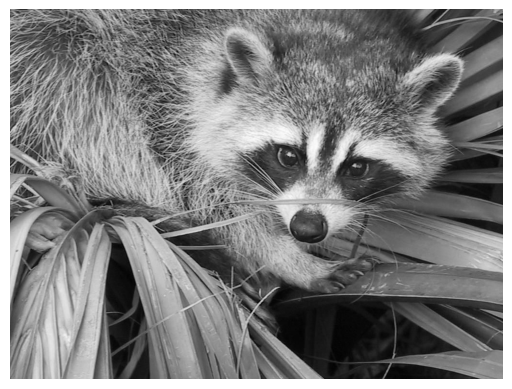

In [13]:
!pip install -q pooch
from scipy import datasets
import matplotlib.pyplot as plt

face = datasets.face(gray=True)
print('forme :', face.shape, 'type :', face.dtype)

plt.imshow(face, cmap=plt.cm.gray)
plt.axis('off')
plt.show()

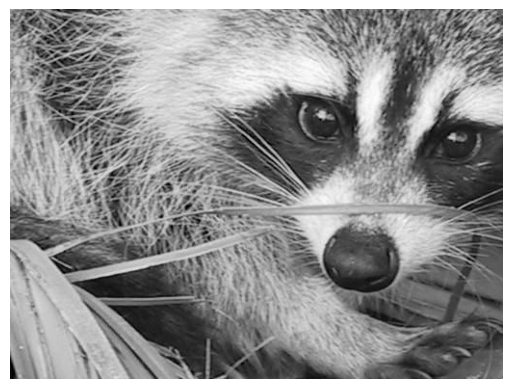

In [14]:
# Zoomer sur le centre par slicing
h, w = face.shape
zoom_face = face[h//4 : -h//4, w//4 : -w//4]
plt.imshow(zoom_face, cmap=plt.cm.gray)
plt.axis('off')
plt.show()

Le slicing du notebook 11 : `h//4 : -h//4` garde la partie centrale en coupant
un quart de chaque côté. Une image n'est qu'un tableau NumPy, donc tout le slicing
s'y applique.

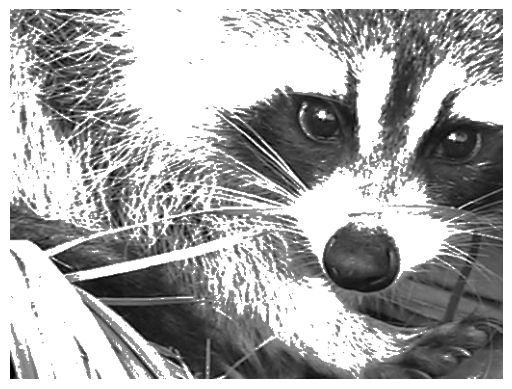

In [15]:
# Seuillage : les pixels clairs deviennent blancs
zoom_face = face[h//4 : -h//4, w//4 : -w//4].copy() # copy() important !
zoom_face[zoom_face > 150] = 255

plt.imshow(zoom_face, cmap=plt.cm.gray)
plt.axis('off')
plt.show()

Le `.copy()` est crucial. Sans lui, `zoom_face` serait une vue sur `face`,
et modifier l'un modifierait l'autre le piège vue/copie du notebook 11. Le
`.copy()` garantit qu'on travaille sur des données indépendantes.

Le masque booléen `zoom_face > 150` sélectionne les pixels clairs, qu'on passe
à 255 (blanc). Le boolean indexing du notebook 11 appliqué à une image.

In [16]:
# Sous-échantillonner : un pixel sur deux
face_reduite = face[::2, ::2]
print('originale :', face.shape)
print('réduite   :', face_reduite.shape, '-> deux fois plus petite')

originale : (768, 1024)
réduite   : (384, 512) -> deux fois plus petite


Le pas `::2` prend un élément sur deux sur les deux axes, l'image est réduite de
moitié dans chaque dimension. Une façon simple de compresser.

### Exercice : standardiser une matrice

Centrer et réduire chaque colonne l'opération du prétraitement.

In [17]:
np.random.seed(0)
A = np.random.randint(0, 100, [10, 5])

D = (A - A.mean(axis=0)) / A.std(axis=0)

print('moyenne par colonne :', D.mean(axis=0).round(10))
print('écart-type par colonne :', D.std(axis=0).round(3))

moyenne par colonne : [-0. -0.  0. -0. -0.]
écart-type par colonne : [1. 1. 1. 1. 1.]


Le `axis=0` est essentiel : on veut la moyenne et l'écart-type par colonne
(par variable), pas sur tout le tableau le piège du notebook 12.

Le résultat a une moyenne de 0 et un écart-type de 1 par colonne. C'est exactement
ce que fait `StandardScaler` du notebook 22, ici à la main. Le broadcasting du
notebook 13 permet de soustraire un vecteur de moyennes à toute la matrice d'un
coup.

## Bloc 3 : Matplotlib

### Exercice : subplots dynamiques

Tracer automatiquement un graphique par expérience d'un dictionnaire.

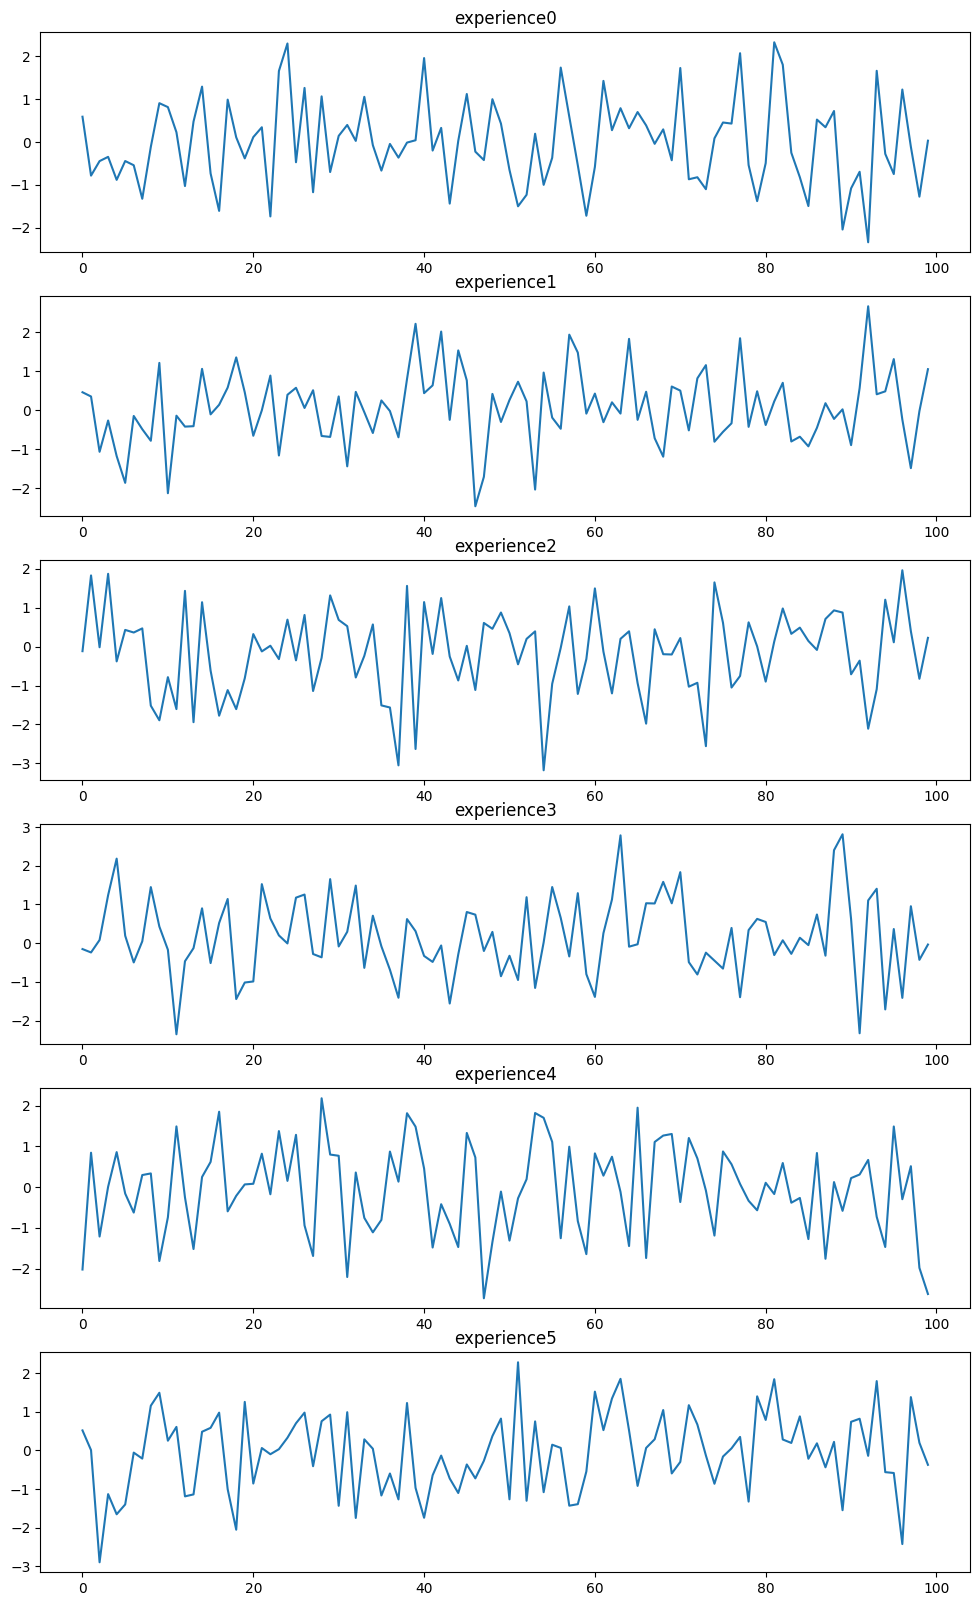

In [18]:
import matplotlib.pyplot as plt
import numpy as np

dataset = {f'experience{i}': np.random.randn(100) for i in range(6)}

def graphique(data):
    n = len(data)
    plt.figure(figsize=(12, 20))
    for k, i in zip(data.keys(), range(1, n+1)):
        plt.subplot(n, 1, i)
        plt.plot(data[k])
        plt.title(k)
    plt.show()

graphique(dataset)

Le nombre de sous-graphiques s'adapte à la taille du dictionnaire pas de
nombre codé en dur. `zip(data.keys(), range(1, n+1))` associe chaque clé à sa
position de subplot. C'est le notebook 14, rendu dynamique.

L'astuce clé : `plt.subplot(n, 1, i)` crée une grille de `n` lignes, 1 colonne, et
place le graphique en position `i`. La fonction marche pour 6 expériences comme
pour 60.

### Exercice : le pairplot d'iris à la main

Reproduire un pairplot simplifié avec des subplots.

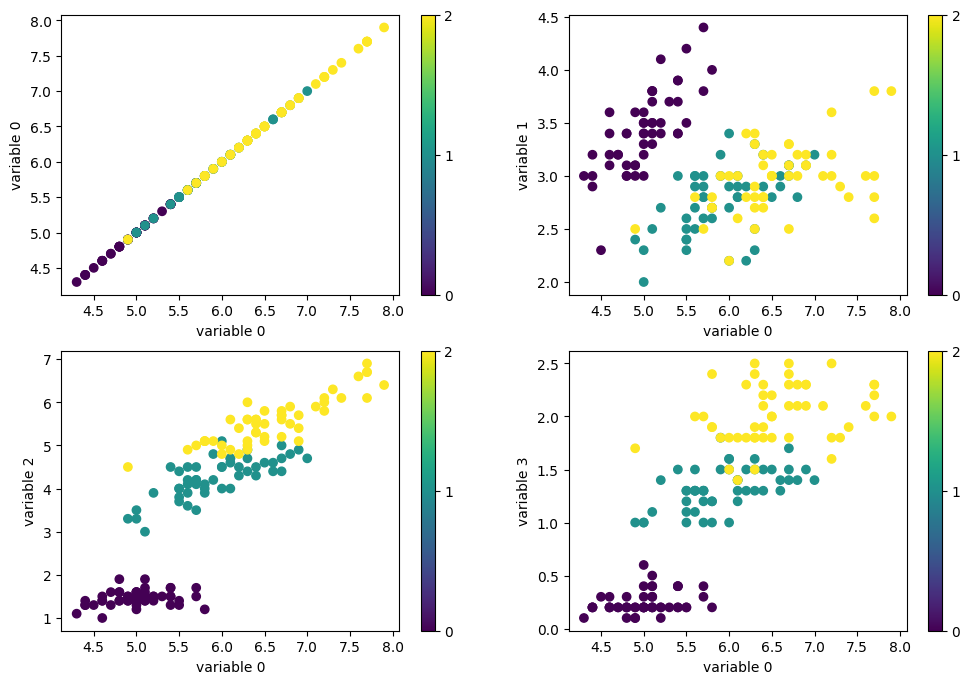

In [19]:
from sklearn.datasets import load_iris

iris = load_iris()
x = iris.data
y = iris.target

n = x.shape[1]
plt.figure(figsize=(12, 8))
for i in range(n):
    plt.subplot(n//2, n//2, i+1)
    plt.scatter(x[:, 0], x[:, i], c=y)
    plt.xlabel('variable 0')
    plt.ylabel(f'variable {i}') # ylabel, pas xlabel deux fois
    plt.colorbar(ticks=list(np.unique(y)))
plt.show()

Le piège corrigé : le code d'origine avait `plt.xlabel('0')` puis
`plt.xlabel(i)` le second écrasait le premier, et l'axe Y n'était jamais
nommé. Il fallait `plt.ylabel` pour le second.

On trace chaque variable contre la première, coloré par espèce. C'est une version
maison du pairplot du notebook 19 on voit quelles variables séparent les espèces.

## Bloc 4 : Pandas

Ces exercices utilisent le Titanic. On le charge via Seaborn.

In [20]:
import seaborn as sns
import pandas as pd

data = sns.load_dataset('titanic')
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Exercice : discrétiser l'âge

Transformer l'âge continu en tranches. Trois méthodes, de la plus lourde à la plus
élégante.

In [21]:
# Méthode manuelle avec .loc
data_manuel = data.copy()
data_manuel.loc[data_manuel['age'] <= 20, 'age'] = 0
data_manuel.loc[(data_manuel['age'] > 20) & (data_manuel['age'] <= 30), 'age'] = 1
data_manuel.loc[(data_manuel['age'] > 30) & (data_manuel['age'] <= 40), 'age'] = 2
data_manuel.loc[data_manuel['age'] > 40, 'age'] = 3

print(data_manuel['age'].value_counts())

age
1.0    230
0.0    179
2.0    155
3.0    150
Name: count, dtype: int64


La méthode `.loc` du notebook 17 modifie les lignes selon une condition. Ça marche,
mais c'est verbeux et répétitif quatre lignes presque identiques.

In [22]:
# Méthode élégante avec pd.cut
data_cut = data.copy()
data_cut['age'] = pd.cut(data_cut['age'],
                         bins=[-1, 20, 30, 40, 200],
                         labels=[0, 1, 2, 3])

print(data_cut['age'].value_counts(dropna=False))

age
1      230
0      179
NaN    177
2      155
3      150
Name: count, dtype: int64


`pd.cut` fait la même chose en une ligne : il découpe en tranches selon les
`bins` et attribue les `labels`. Bien plus lisible et moins sujet aux erreurs. Le
`value_counts(dropna=False)` montre aussi les âges manquants (`NaN`), qui ne
tombent dans aucune tranche.

### Vérifier le lien avec la survie

In [23]:
print(data_cut.groupby('age', observed=True)['survived'].mean())

age
0    0.458101
1    0.365217
2    0.445161
3    0.366667
Name: survived, dtype: float64


On regroupe par tranche d'âge et on calcule le taux de survie le `groupby` du
notebook 17. On voit si l'âge influence la survie, ce qui prépare une future
modélisation.

### Exercice : catégoriser en texte avec une fonction

In [24]:
def category_ages(age):
    if pd.isna(age):
        return 'inconnu'
    elif age <= 20:
        return '<20 ans'
    elif age <= 30:
        return '20-30 ans'
    elif age <= 40:
        return '30-40 ans'
    else:
        return '+40 ans'

data_texte = sns.load_dataset('titanic')
print(data_texte['age'].map(category_ages).value_counts())

age
20-30 ans    230
<20 ans      179
inconnu      177
30-40 ans    155
+40 ans      150
Name: count, dtype: int64


`map` applique une fonction personnalisée à chaque valeur le notebook 17. La
gestion du `pd.isna(age)` en premier est importante : sans elle, les NaN
provoqueraient des comparaisons impossibles. On traite explicitement le cas
« inconnu ».

### Exercice : encoder une variable catégorielle

Trois façons de transformer le sexe en 0/1.

In [25]:
data = sns.load_dataset('titanic')

# 1. map avec un dictionnaire
v1 = data['sex'].map({'male': 0, 'female': 1})

# 2. replace avec deux listes
v2 = data['sex'].replace(['male', 'female'], [0, 1])

# 3. codes de catégorie automatiques
v3 = data['sex'].astype('category').cat.codes

print('map     :', v1.head(3).tolist())
print('replace :', v2.head(3).tolist())
print('cat.codes:', v3.head(3).tolist())

map     : [0, 1, 1]
replace : [0, 1, 1]
cat.codes: [1, 0, 0]


/tmp/ipykernel_1016/3634030713.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  v2 = data['sex'].replace(['male', 'female'], [0, 1])


Trois méthodes équivalentes pour l'encodage binaire du notebook 22 :

`map` avec un dictionnaire le plus explicite, on contrôle chaque valeur.
Attention à l'orthographe : `'female'`, pas `'femal'`, sinon la valeur devient NaN.

`replace` avec deux listes pratique pour plusieurs remplacements.

`cat.codes` automatique, mais on ne contrôle pas quel code va à quelle
catégorie (ordre alphabétique). Rapide, mais moins explicite.

Le `map` est souvent le meilleur choix : clair et sans surprise.

## Bloc 5 Projet : stratégie de trading Bitcoin

Un mini-projet du notebook 18 : une stratégie « Turtle » sur le Bitcoin. On achète
quand le cours dépasse son maximum récent, on vend quand il passe sous son minimum.

*Note : ceci est un exercice pédagogique, pas un conseil d'investissement.*

In [26]:
%matplotlib inline
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

data = yf.download('BTC-EUR', start='2015-01-01', interval='1d')

# Aplatir les colonnes MultiIndex, avant tout ajout
data.columns = data.columns.get_level_values(0)
print(data.columns.tolist())

/tmp/ipykernel_1016/171276340.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('BTC-EUR', start='2015-01-01', interval='1d')
[*********************100%***********************]  1 of 1 completed

['Close', 'High', 'Low', 'Open', 'Volume']


Le piège yfinance, corrigé une fois pour toutes. `yf.download` renvoie des
colonnes en MultiIndex `(Price, Ticker)`. Sans les aplatir, `data['Close']`
renvoie un DataFrame au lieu d'une Series, et tout casse ensuite.

`data.columns = data.columns.get_level_values(0)` garde le premier niveau (`Close`,
`High`...). À faire immédiatement après le download, avant d'ajouter la moindre
colonne sinon on aplatit aussi les colonnes qu'on vient de créer. C'est pour ça
qu'on ne le répète pas trois fois comme dans le brouillon : une seule fois, au bon
endroit.

In [27]:
# La stratégie Turtle
data['Buy'] = np.zeros(len(data))
data['Sell'] = np.zeros(len(data))

# Maximum et minimum des 28 jours PRÉCÉDENTS
data['RollingMax'] = data['Close'].shift(1).rolling(window=28).max()
data['RollingMin'] = data['Close'].shift(1).rolling(window=28).min()

# Signal d'achat / de vente
data.loc[data['RollingMax'] < data['Close'], 'Buy'] = 1
data.loc[data['RollingMin'] > data['Close'], 'Sell'] = -1

print('signaux achat :', int(data['Buy'].sum()))
print('signaux vente :', int(-data['Sell'].sum()))

signaux achat : 549
signaux vente : 276


Le `shift(1)` est crucial. On calcule le max/min des 28 jours précédents,
pas incluant aujourd'hui. Sans le `shift(1)`, on utiliserait le cours du jour même
pour décider d'acheter ce jour-là un look-ahead bias, on tricherait avec des
informations du futur. Le décalage garantit qu'on ne décide qu'avec le passé.

C'est la même rigueur que le `TimeSeriesSplit` du notebook 21.1 : sur une série
temporelle, ne jamais utiliser le futur pour prédire le passé.

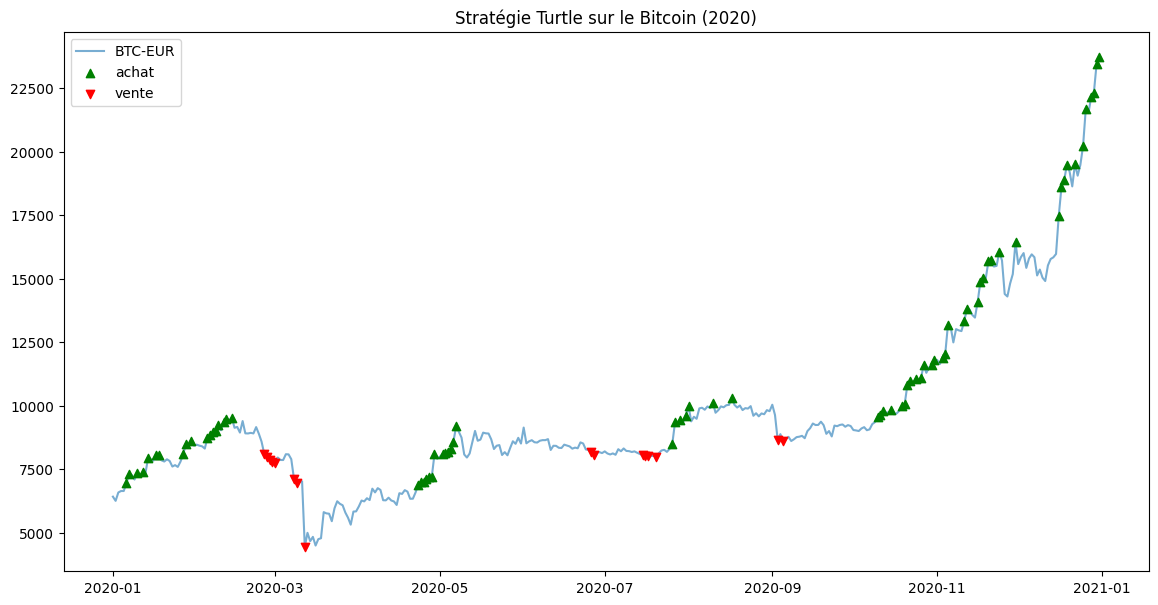

In [28]:
# Visualiser sur une année
debut, fin = '2020', '2020'

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(data.loc[debut:fin, 'Close'], label='BTC-EUR', alpha=0.6)

achats = data.loc[debut:fin][data.loc[debut:fin, 'Buy'] == 1]
ventes = data.loc[debut:fin][data.loc[debut:fin, 'Sell'] == -1]

ax.scatter(achats.index, achats['Close'], marker='^', c='green', label='achat', zorder=5)
ax.scatter(ventes.index, ventes['Close'], marker='v', c='red', label='vente', zorder=5)
ax.legend()
plt.title('Stratégie Turtle sur le Bitcoin (2020)')
plt.show()

On visualise les signaux sur 2020. Les triangles verts sont les achats (cours en
hausse), les rouges les ventes (cours en baisse).

`plt.subplots` (au pluriel) du notebook 15 permet le `fig, ax` et un contrôle fin.
La sélection par date `data.loc['2020':'2020']` marche grâce à l'index temporel du
notebook 18.

Ce que le projet illustre. Une stratégie de trading n'est qu'une suite de
conditions sur des données rolling windows, décalages, masques booléens. Toutes
les briques viennent du cours. Et le piège du look-ahead rappelle que sur les
séries temporelles, l'ordre du temps est sacré.

## Mémo : les pièges rencontrés

| Exercice | Piège | Correction |
|---|---|---|
| Tri dico | `return` mal indenté | dans la fonction |
| Tri dico | `'nombre'` au lieu de `nombre` | la variable, pas la chaîne |
| Fichiers | `f.read.splitlines()` | `f.read()` avec parenthèses |
| Fichiers | `line.strip` | `line.strip()` |
| Image | vue au lieu de copie | `.copy()` avant modification |
| Standardisation | `.mean()` sans axis | `axis=0` pour les colonnes |
| Pairplot | deux `xlabel` | `ylabel` pour le second |
| Encodage | `'femal'` | `'female'` |
| Trading | pas de `shift(1)` | décaler pour éviter le look-ahead |
| Trading | MultiIndex yfinance | `get_level_values(0)` une fois |

Ces exercices montrent que la théorie du cours se transpose directement en
solutions concrètes et que les mêmes pièges reviennent : méthode sans
parenthèses, vue contre copie, axis oublié, et le futur qui fuit dans le passé sur
les séries temporelles.